In [1]:
# ==========================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ==========================================

!pip install -q xgboost lightgbm shap

In [7]:

df = pd.read_csv("/content/DT_Placement.csv")

In [8]:
# ==========================================
# CELL 2: IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

print("All libraries imported successfully!")

All libraries imported successfully!


In [10]:
df = pd.read_csv("/content/DT_Placement.csv")

In [9]:
# ==========================================
# CELL 5: DATASET INFORMATION
# ==========================================

print("==========================================")
print("DATASET INFORMATION")
print("==========================================")

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

DATASET INFORMATION

Shape of Dataset:
(14, 6)

Column Names:
['ID', 'CGPA', 'Internships', 'Backlogs', 'Aptitude', 'Placed']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           14 non-null     object 
 1   CGPA         14 non-null     float64
 2   Internships  14 non-null     int64  
 3   Backlogs     14 non-null     object 
 4   Aptitude     14 non-null     int64  
 5   Placed       14 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 804.0+ bytes

Missing Values:
ID             0
CGPA           0
Internships    0
Backlogs       0
Aptitude       0
Placed         0
dtype: int64


In [11]:
# ==========================================
# CELL 6: STATISTICAL INFORMATION
# ==========================================

print("==========================================")
print("STATISTICAL SUMMARY")
print("==========================================")

print(df.describe())

STATISTICAL SUMMARY
            CGPA  Internships   Aptitude
count  14.000000    14.000000  14.000000
mean    7.064286     0.928571  69.142857
std     1.447336     0.828742  15.864121
min     5.000000     0.000000  44.000000
25%     6.200000     0.000000  54.750000
50%     6.800000     1.000000  73.000000
75%     8.325000     1.750000  80.000000
max     9.400000     2.000000  96.000000


In [12]:
# ==========================================
# CELL 7: ENCODE CATEGORICAL VARIABLES
# ==========================================

# Backlogs:
# No  -> 0
# Yes -> 1

df["Backlogs"] = df["Backlogs"].map({
    "No": 0,
    "Yes": 1
})

# Placed:
# No  -> 0
# Yes -> 1

df["Placed"] = df["Placed"].map({
    "No": 0,
    "Yes": 1
})

print("Categorical variables encoded successfully!\n")
print(df)

Categorical variables encoded successfully!

     ID  CGPA  Internships  Backlogs  Aptitude  Placed
0    S1   8.6            2         0        73       1
1    S2   9.4            2         0        76       1
2    S3   9.0            2         0        81       1
3    S4   5.2            0         1        48       0
4    S5   5.3            0         1        44       0
5    S6   5.0            1         0        83       0
6    S7   6.2            1         1        63       0
7    S8   6.2            0         1        52       1
8    S9   8.7            2         1        77       1
9   S10   7.5            1         0        70       1
10  S11   6.7            1         0        96       1
11  S12   7.5            1         0        84       1
12  S13   6.8            0         1        48       0
13  S14   6.8            0         0        73       0


In [13]:
# ==========================================
# CELL 8: CHECK ENCODED DATA
# ==========================================

print("==========================================")
print("ENCODED DATASET")
print("==========================================")

print(df)

print("\nData Types:")
print(df.dtypes)

ENCODED DATASET
     ID  CGPA  Internships  Backlogs  Aptitude  Placed
0    S1   8.6            2         0        73       1
1    S2   9.4            2         0        76       1
2    S3   9.0            2         0        81       1
3    S4   5.2            0         1        48       0
4    S5   5.3            0         1        44       0
5    S6   5.0            1         0        83       0
6    S7   6.2            1         1        63       0
7    S8   6.2            0         1        52       1
8    S9   8.7            2         1        77       1
9   S10   7.5            1         0        70       1
10  S11   6.7            1         0        96       1
11  S12   7.5            1         0        84       1
12  S13   6.8            0         1        48       0
13  S14   6.8            0         0        73       0

Data Types:
ID              object
CGPA           float64
Internships      int64
Backlogs         int64
Aptitude         int64
Placed           int64
dtype: o

In [14]:
# ==========================================
# CELL 9: FEATURES AND TARGET
# ==========================================

# Remove ID and target from features
X = df.drop(["ID", "Placed"], axis=1)

# Target variable
y = df["Placed"]

print("==========================================")
print("FEATURES")
print("==========================================")

print(X)

print("\n==========================================")
print("TARGET")
print("==========================================")

print(y)

FEATURES
    CGPA  Internships  Backlogs  Aptitude
0    8.6            2         0        73
1    9.4            2         0        76
2    9.0            2         0        81
3    5.2            0         1        48
4    5.3            0         1        44
5    5.0            1         0        83
6    6.2            1         1        63
7    6.2            0         1        52
8    8.7            2         1        77
9    7.5            1         0        70
10   6.7            1         0        96
11   7.5            1         0        84
12   6.8            0         1        48
13   6.8            0         0        73

TARGET
0     1
1     1
2     1
3     0
4     0
5     0
6     0
7     1
8     1
9     1
10    1
11    1
12    0
13    0
Name: Placed, dtype: int64


In [15]:
# ==========================================
# CELL 10: TRAIN / VALIDATION SPLIT
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("==========================================")
print("DATA SPLIT")
print("==========================================")

print("Total samples       :", len(X))
print("Training samples    :", len(X_train))
print("Validation samples  :", len(X_val))

DATA SPLIT
Total samples       : 14
Training samples    : 9
Validation samples  : 5


In [16]:
# ==========================================
# CELL 11: DISPLAY SPLIT DATA
# ==========================================

print("Training Features:")
print(X_train)

print("\nTraining Target:")
print(y_train)

print("\nValidation Features:")
print(X_val)

print("\nValidation Target:")
print(y_val)

Training Features:
    CGPA  Internships  Backlogs  Aptitude
3    5.2            0         1        48
0    8.6            2         0        73
7    6.2            0         1        52
4    5.3            0         1        44
2    9.0            2         0        81
13   6.8            0         0        73
5    5.0            1         0        83
9    7.5            1         0        70
10   6.7            1         0        96

Training Target:
3     0
0     1
7     1
4     0
2     1
13    0
5     0
9     1
10    1
Name: Placed, dtype: int64

Validation Features:
    CGPA  Internships  Backlogs  Aptitude
8    8.7            2         1        77
1    9.4            2         0        76
12   6.8            0         1        48
11   7.5            1         0        84
6    6.2            1         1        63

Validation Target:
8     1
1     1
12    0
11    1
6     0
Name: Placed, dtype: int64


In [17]:
# ==========================================
# CELL 12: ADABOOST
# ==========================================

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

start_time = time.perf_counter()

ada.fit(X_train, y_train)

end_time = time.perf_counter()

ada_training_time = end_time - start_time

# Predictions
ada_train_pred = ada.predict(X_train)
ada_val_pred = ada.predict(X_val)

# Accuracy
ada_train_accuracy = accuracy_score(
    y_train,
    ada_train_pred
)

ada_val_accuracy = accuracy_score(
    y_val,
    ada_val_pred
)

print("==========================================")
print("ADABOOST RESULTS")
print("==========================================")

print("Training Accuracy   :", ada_train_accuracy)
print("Validation Accuracy :", ada_val_accuracy)
print("Training Time       :", ada_training_time)

ADABOOST RESULTS
Training Accuracy   : 1.0
Validation Accuracy : 0.8
Training Time       : 0.33839138100006494


In [18]:
# ==========================================
# CELL 13: ADABOOST ESTIMATOR WEIGHTS
# ==========================================

print("==========================================")
print("ADABOOST ESTIMATOR WEIGHTS")
print("==========================================")

for i, weight in enumerate(ada.estimator_weights_):
    print(f"Estimator {i + 1}: {weight:.4f}")

ADABOOST ESTIMATOR WEIGHTS
Estimator 1: 0.2079
Estimator 2: 0.1871
Estimator 3: 0.1684
Estimator 4: 0.1516
Estimator 5: 0.1392
Estimator 6: 0.1401
Estimator 7: 0.1290
Estimator 8: 0.1298
Estimator 9: 0.1199
Estimator 10: 0.1206
Estimator 11: 0.1345
Estimator 12: 0.1125
Estimator 13: 0.1103
Estimator 14: 0.1051
Estimator 15: 0.1031
Estimator 16: 0.0985
Estimator 17: 0.1222
Estimator 18: 0.0927
Estimator 19: 0.0952
Estimator 20: 0.0874
Estimator 21: 0.1125
Estimator 22: 0.0828
Estimator 23: 0.0880
Estimator 24: 0.0784
Estimator 25: 0.1037
Estimator 26: 0.0748
Estimator 27: 0.0814
Estimator 28: 0.0711
Estimator 29: 0.0768
Estimator 30: 0.0678
Estimator 31: 0.0949
Estimator 32: 0.0652
Estimator 33: 0.0587
Estimator 34: 0.0744
Estimator 35: 0.0567
Estimator 36: 0.0904
Estimator 37: 0.0917
Estimator 38: 0.0595
Estimator 39: 0.0883
Estimator 40: 0.0578
Estimator 41: 0.0923
Estimator 42: 0.0563
Estimator 43: 0.0899
Estimator 44: 0.0727
Estimator 45: 0.0587
Estimator 46: 0.0887
Estimator 47: 0.

In [19]:
# ==========================================
# CELL 14: GRADIENT BOOSTING
# ==========================================

gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

start_time = time.perf_counter()

gbc.fit(X_train, y_train)

end_time = time.perf_counter()

gbc_training_time = end_time - start_time

# Predictions
gbc_train_pred = gbc.predict(X_train)
gbc_val_pred = gbc.predict(X_val)

# Accuracy
gbc_train_accuracy = accuracy_score(
    y_train,
    gbc_train_pred
)

gbc_val_accuracy = accuracy_score(
    y_val,
    gbc_val_pred
)

print("==========================================")
print("GRADIENT BOOSTING RESULTS")
print("==========================================")

print("Training Accuracy   :", gbc_train_accuracy)
print("Validation Accuracy :", gbc_val_accuracy)
print("Training Time       :", gbc_training_time)

GRADIENT BOOSTING RESULTS
Training Accuracy   : 1.0
Validation Accuracy : 0.6
Training Time       : 0.18119886400018004


In [20]:
# ==========================================
# CELL 15: XGBOOST
# ==========================================

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

start_time = time.perf_counter()

xgb.fit(X_train, y_train)

end_time = time.perf_counter()

xgb_training_time = end_time - start_time

# Predictions
xgb_train_pred = xgb.predict(X_train)
xgb_val_pred = xgb.predict(X_val)

# Accuracy
xgb_train_accuracy = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_accuracy = accuracy_score(
    y_val,
    xgb_val_pred
)

print("==========================================")
print("XGBOOST RESULTS")
print("==========================================")

print("Training Accuracy   :", xgb_train_accuracy)
print("Validation Accuracy :", xgb_val_accuracy)
print("Training Time       :", xgb_training_time)

XGBOOST RESULTS
Training Accuracy   : 0.5555555555555556
Validation Accuracy : 0.6
Training Time       : 0.06995555000003151


In [21]:
# ==========================================
# CELL 16: LIGHTGBM
# ==========================================

lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

start_time = time.perf_counter()

lgb.fit(X_train, y_train)

end_time = time.perf_counter()

lgb_training_time = end_time - start_time

# Predictions
lgb_train_pred = lgb.predict(X_train)
lgb_val_pred = lgb.predict(X_val)

# Accuracy
lgb_train_accuracy = accuracy_score(
    y_train,
    lgb_train_pred
)

lgb_val_accuracy = accuracy_score(
    y_val,
    lgb_val_pred
)

print("==========================================")
print("LIGHTGBM RESULTS")
print("==========================================")

print("Training Accuracy   :", lgb_train_accuracy)
print("Validation Accuracy :", lgb_val_accuracy)
print("Training Time       :", lgb_training_time)

LIGHTGBM RESULTS
Training Accuracy   : 0.5555555555555556
Validation Accuracy : 0.6
Training Time       : 0.08690006000006179


In [22]:
# ==========================================
# CELL 17: MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM"
    ],

    "Training Accuracy": [
        ada_train_accuracy,
        gbc_train_accuracy,
        xgb_train_accuracy,
        lgb_train_accuracy
    ],

    "Validation Accuracy": [
        ada_val_accuracy,
        gbc_val_accuracy,
        xgb_val_accuracy,
        lgb_val_accuracy
    ],

    "Training Time (sec)": [
        ada_training_time,
        gbc_training_time,
        xgb_training_time,
        lgb_training_time
    ]
})

# Sort according to validation accuracy
results = results.sort_values(
    by="Validation Accuracy",
    ascending=False
).reset_index(drop=True)

print("==========================================")
print("BOOSTING BENCHMARK RESULTS")
print("==========================================")

display(results)

BOOSTING BENCHMARK RESULTS


,Model,Training Accuracy,Validation Accuracy,Training Time (sec)
0,AdaBoost,1.000000,0.8,0.338391
1,Gradient Boosting,1.000000,0.6,0.181199
2,XGBoost,0.555556,0.6,0.069956
3,LightGBM,0.555556,0.6,0.086900


In [23]:
# ==========================================
# CELL 18: ACCURACY IN PERCENTAGE
# ==========================================

results_percentage = results.copy()

results_percentage["Training Accuracy"] = (
    results_percentage["Training Accuracy"] * 100
)

results_percentage["Validation Accuracy"] = (
    results_percentage["Validation Accuracy"] * 100
)

print("==========================================")
print("ACCURACY COMPARISON (%)")
print("==========================================")

display(results_percentage)

ACCURACY COMPARISON (%)


,Model,Training Accuracy,Validation Accuracy,Training Time (sec)
0,AdaBoost,100.000000,80.0,0.338391
1,Gradient Boosting,100.000000,60.0,0.181199
2,XGBoost,55.555556,60.0,0.069956
3,LightGBM,55.555556,60.0,0.086900


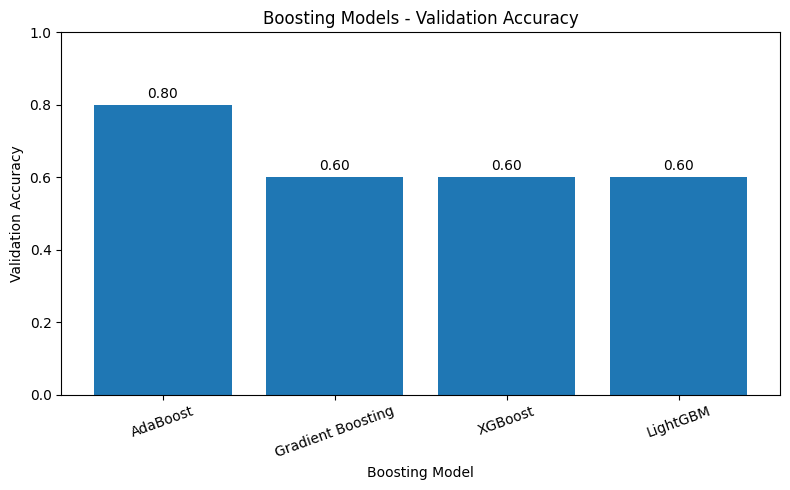

In [24]:
# ==========================================
# CELL 19: VALIDATION ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Validation Accuracy"]
)

plt.xlabel("Boosting Model")
plt.ylabel("Validation Accuracy")
plt.title("Boosting Models - Validation Accuracy")

plt.ylim(0, 1)

for i, value in enumerate(results["Validation Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

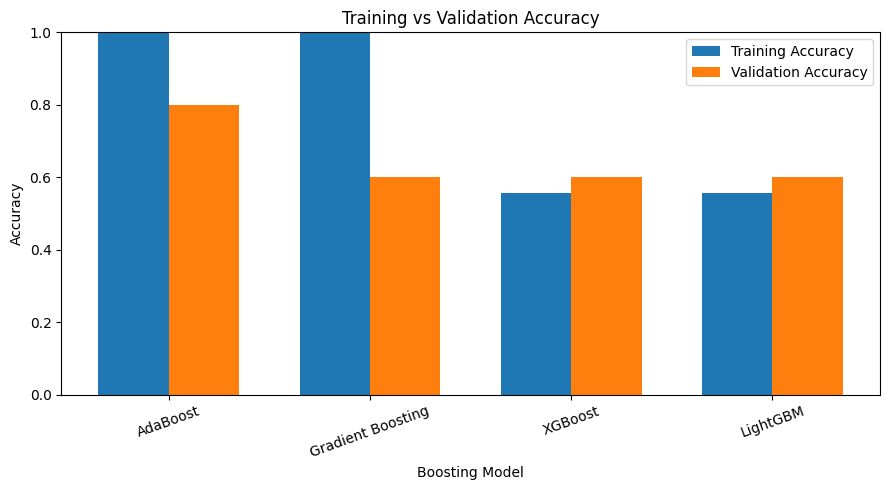

In [25]:
# ==========================================
# CELL 20: TRAINING VS VALIDATION ACCURACY
# ==========================================

x = np.arange(len(results["Model"]))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    results["Training Accuracy"],
    width,
    label="Training Accuracy"
)

plt.bar(
    x + width / 2,
    results["Validation Accuracy"],
    width,
    label="Validation Accuracy"
)

plt.xlabel("Boosting Model")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.xticks(
    x,
    results["Model"],
    rotation=20
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

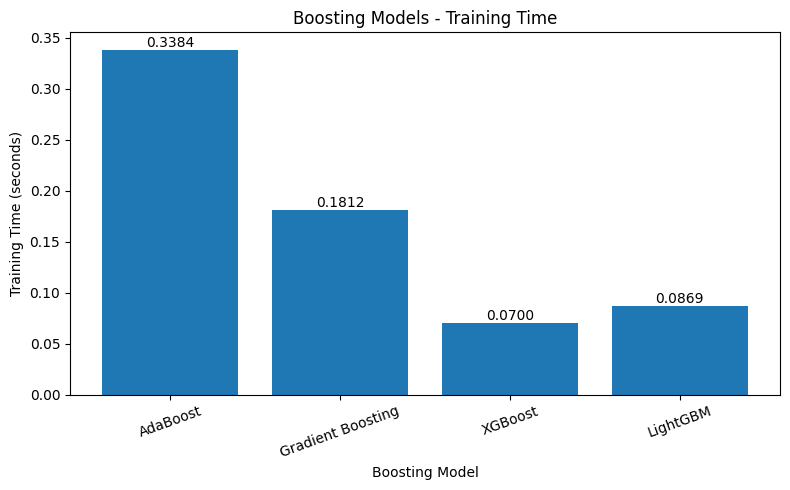

In [26]:
# ==========================================
# CELL 21: TRAINING TIME COMPARISON
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Training Time (sec)"]
)

plt.xlabel("Boosting Model")
plt.ylabel("Training Time (seconds)")
plt.title("Boosting Models - Training Time")

plt.xticks(rotation=20)

for i, value in enumerate(results["Training Time (sec)"]):
    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

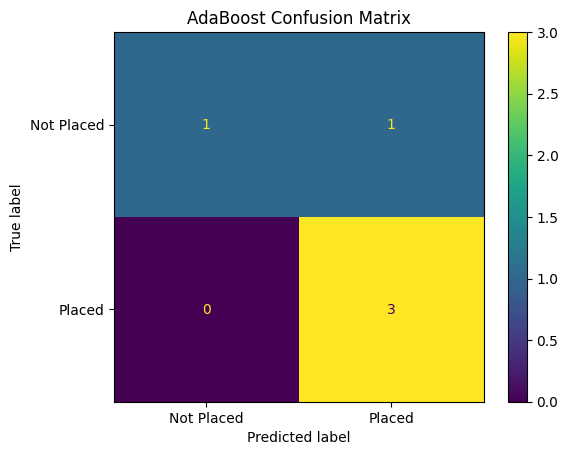

In [27]:
# ==========================================
# CELL 22: ADABOOST CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_val,
    ada_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title("AdaBoost Confusion Matrix")
plt.show()

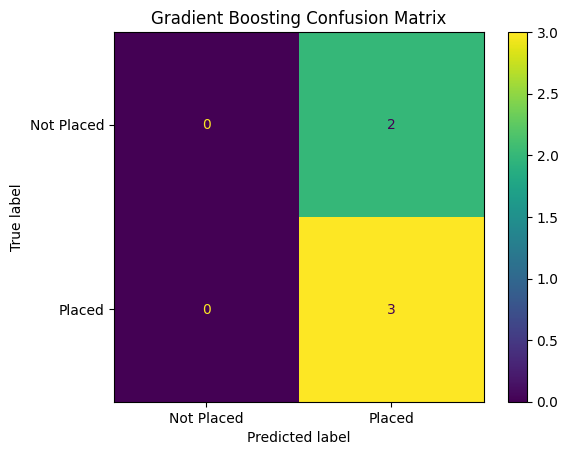

In [28]:
# ==========================================
# CELL 23: GRADIENT BOOSTING CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_val,
    gbc_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

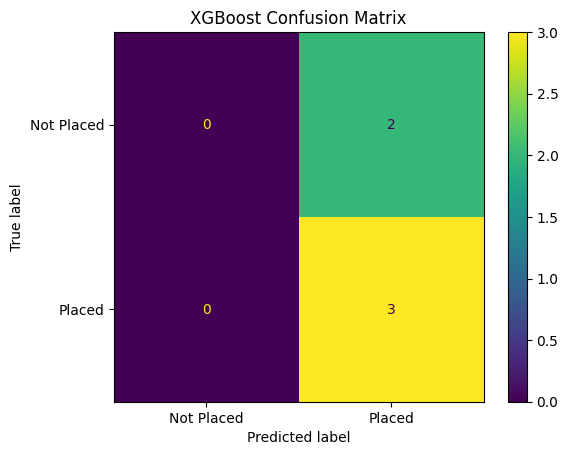

In [29]:
# ==========================================
# CELL 24: XGBOOST CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_val,
    xgb_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

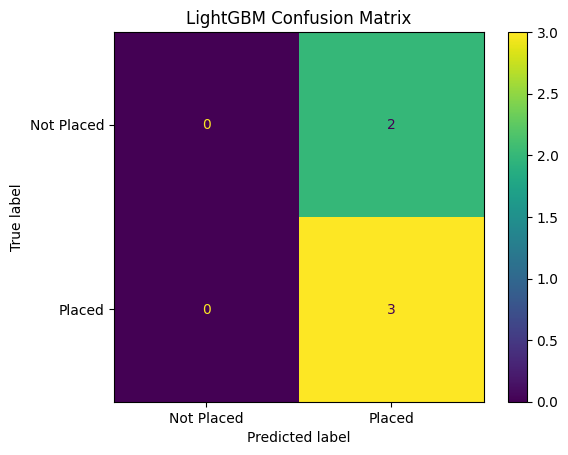

In [30]:
# ==========================================
# CELL 25: LIGHTGBM CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_val,
    lgb_val_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()

plt.title("LightGBM Confusion Matrix")
plt.show()

In [31]:
# ==========================================
# CELL 26: BEST MODEL
# ==========================================

best_model_name = results.iloc[0]["Model"]

print("==========================================")
print("BEST MODEL")
print("==========================================")

print("Best Model:", best_model_name)
print(
    "Validation Accuracy:",
    results.iloc[0]["Validation Accuracy"]
)

BEST MODEL
Best Model: AdaBoost
Validation Accuracy: 0.8


In [32]:
# ==========================================
# CELL 27: CLASSIFICATION REPORTS
# ==========================================

print("==========================================")
print("ADABOOST CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_val,
        ada_val_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0
    )
)


print("==========================================")
print("GRADIENT BOOSTING CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_val,
        gbc_val_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0
    )
)


print("==========================================")
print("XGBOOST CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_val,
        xgb_val_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0
    )
)


print("==========================================")
print("LIGHTGBM CLASSIFICATION REPORT")
print("==========================================")

print(
    classification_report(
        y_val,
        lgb_val_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0
    )
)

ADABOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Placed       1.00      0.50      0.67         2
      Placed       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

GRADIENT BOOSTING CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Placed       0.00      0.00      0.00         2
      Placed       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Placed       0.00      0.00      0.00         2
      Placed       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30    

In [33]:
# ==========================================
# CELL 28: XGBOOST FEATURE IMPORTANCE
# ==========================================

importance = xgb.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("==========================================")
print("XGBOOST FEATURE IMPORTANCE")
print("==========================================")

display(feature_importance)

XGBOOST FEATURE IMPORTANCE


,Feature,Importance
0,CGPA,0.0
1,Internships,0.0
2,Backlogs,0.0
3,Aptitude,0.0


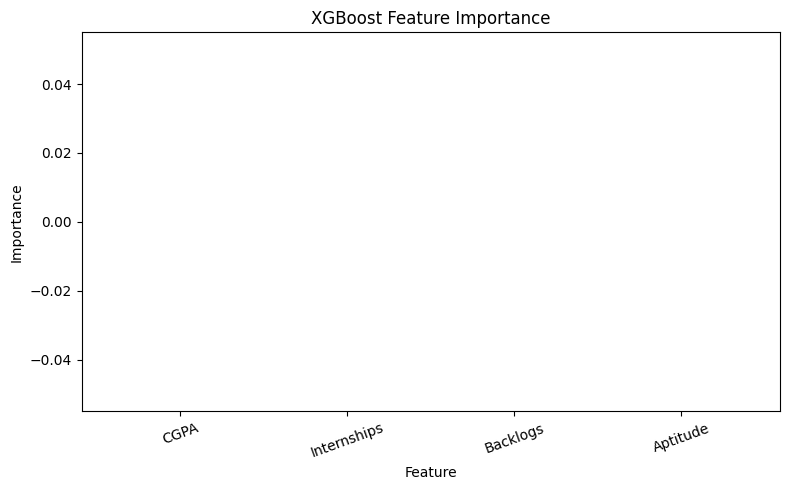

In [34]:
# ==========================================
# CELL 29: FEATURE IMPORTANCE GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [35]:
# ==========================================
# CELL 30: SHAP EXPLAINER
# ==========================================

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_val)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


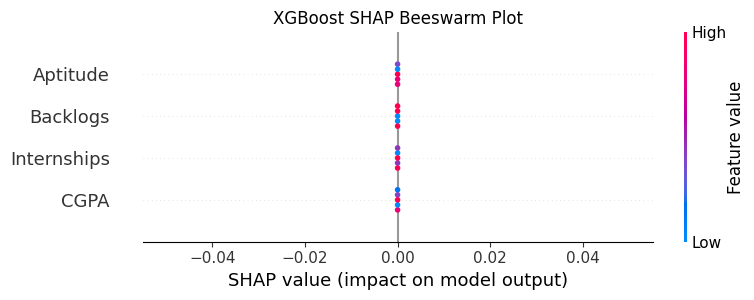

In [36]:
# ==========================================
# CELL 31: SHAP BEESWARM PLOT
# ==========================================

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="dot",
    show=False
)

plt.title("XGBoost SHAP Beeswarm Plot")

plt.tight_layout()
plt.show()

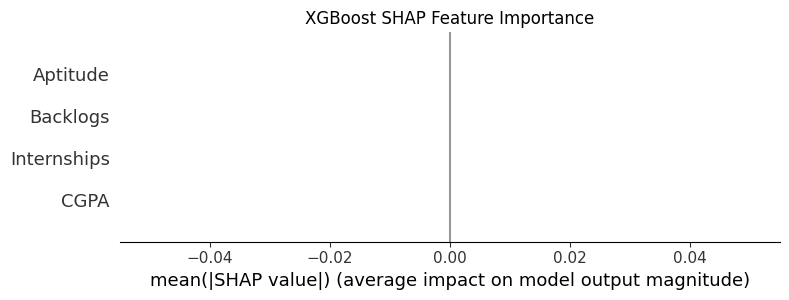

In [37]:
# ==========================================
# CELL 32: SHAP FEATURE IMPORTANCE
# ==========================================

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    show=False
)

plt.title("XGBoost SHAP Feature Importance")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================
# CELL 33: NEW STUDENT PREDICTION
# ==========================================

new_student = pd.DataFrame({
    "CGPA": [8.5],
    "Internships": [2],
    "Backlogs": [0],
    "Aptitude": [80]
})

print("New Student:")
print(new_student)

New Student:
   CGPA  Internships  Backlogs  Aptitude
0   8.5            2         0        80


In [39]:
# ==========================================
# CELL 34: PREDICTION USING ALL MODELS
# ==========================================

ada_prediction = ada.predict(new_student)[0]
gbc_prediction = gbc.predict(new_student)[0]
xgb_prediction = xgb.predict(new_student)[0]
lgb_prediction = lgb.predict(new_student)[0]

def convert_prediction(value):
    if value == 1:
        return "Placed"
    else:
        return "Not Placed"


print("==========================================")
print("NEW STUDENT PREDICTION")
print("==========================================")

print("AdaBoost          :", convert_prediction(ada_prediction))
print("Gradient Boosting :", convert_prediction(gbc_prediction))
print("XGBoost           :", convert_prediction(xgb_prediction))
print("LightGBM          :", convert_prediction(lgb_prediction))

NEW STUDENT PREDICTION
AdaBoost          : Placed
Gradient Boosting : Placed
XGBoost           : Placed
LightGBM          : Placed


In [40]:
# ==========================================
# CELL 35: XGBOOST PLACEMENT PROBABILITY
# ==========================================

probability = xgb.predict_proba(new_student)[0][1]

print("==========================================")
print("XGBOOST PREDICTION")
print("==========================================")

print(
    f"Probability of Placement: {probability * 100:.2f}%"
)

if probability >= 0.5:
    print("Prediction: PLACED")
else:
    print("Prediction: NOT PLACED")

XGBOOST PREDICTION
Probability of Placement: 55.56%
Prediction: PLACED


In [41]:
# ==========================================
# CELL 36: FINAL SUMMARY
# ==========================================

print("\n")
print("=" * 60)
print("FINAL BOOSTING MODEL SUMMARY")
print("=" * 60)

for _, row in results.iterrows():

    print(
        f"{row['Model']:20s} | "
        f"Train: {row['Training Accuracy']:.2f} | "
        f"Validation: {row['Validation Accuracy']:.2f} | "
        f"Time: {row['Training Time (sec)']:.6f}s"
    )

print("=" * 60)

print("\nBest Model:")
print(best_model_name)

print(
    f"Best Validation Accuracy: "
    f"{results.iloc[0]['Validation Accuracy']:.2%}"
)

print("=" * 60)



FINAL BOOSTING MODEL SUMMARY
AdaBoost             | Train: 1.00 | Validation: 0.80 | Time: 0.338391s
Gradient Boosting    | Train: 1.00 | Validation: 0.60 | Time: 0.181199s
XGBoost              | Train: 0.56 | Validation: 0.60 | Time: 0.069956s
LightGBM             | Train: 0.56 | Validation: 0.60 | Time: 0.086900s

Best Model:
AdaBoost
Best Validation Accuracy: 80.00%
